# day 34 prep

working on over-relaxation and gauss-seidel methods

## first over-relaxation

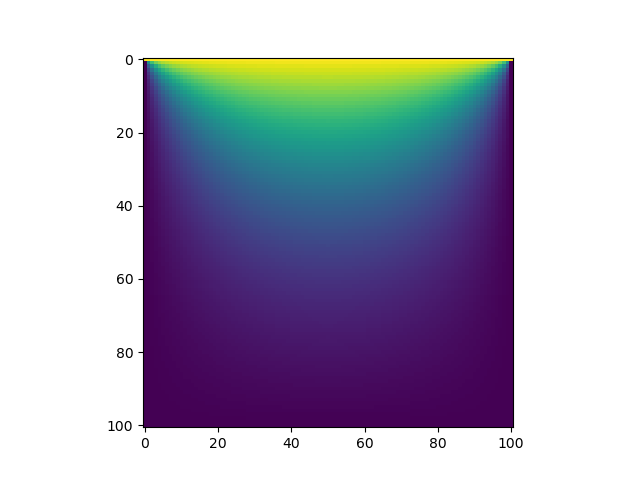

In [1]:
M = 100 # grid size
V = 1.0 # voltage

target = 2**-16

phi = np.zeros([M+1, M+1], float)
phi[0, :] = V

phiprime = np.empty([M+1,M+1], float)

delta = 1.0

while delta>target:
    for i in range(M+1):
        for j in range(M+1):
            if i == 0 or i == M or j==0 or j==M:
                phiprime[i,j] = phi[i,j]
            else:
                phiprime[i,j] = (phi[i+1,j]+phi[i-1,j]+phi[i,j+1]+phi[i,j-1])/4 
    delta = np.max(np.abs(phi-phiprime))
    phi, phiprime = phiprime, phi

fig0, ax0 = plt.subplots()
ax0.imshow(phi)

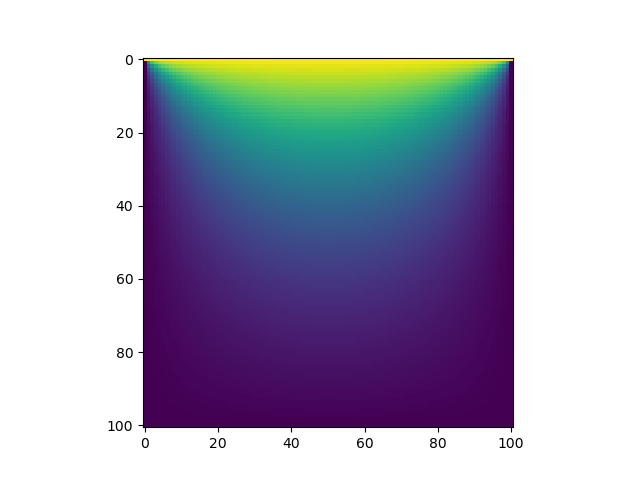

In [2]:
phi = np.zeros([M+1, M+1], float)
phi[0,:] = V

dphi = np.empty([M+1,M+1],float)

delta = 1.0
while delta>target:
    for i in range(M+1):
        for j in range(M+1):
            if i==0 or i==M or j==0 or j==M: # so this is around the boundary
                #phiprime[i,j] = phi[i,j]
                phi[i,j] = phi[i,j]
                dphi[i,j] = 0
            else:
                dphi[i,j] = (phi[i+1,j]+phi[i-1,j]+phi[i,j+1]+phi[i,j-1])/4-phi[i,j]
                phi[i,j] = phi[i,j]+dphi[i,j]
    delta = np.max(np.abs(dphi))
    # phi, phiprime = phiprime, phi

fig1, ax1 = plt.subplots()
ax1.imshow(phi)

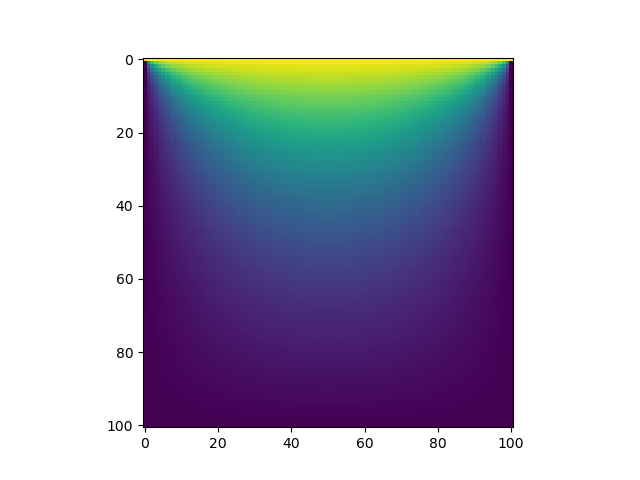

In [3]:
phi = np.zeros([M+1, M+1], float)
phi[0,:] = V
# phi[M,:] = V

dphi = np.empty([M+1,M+1],float)
omega = 0.9

delta = 1.0
while delta>target:
    for i in range(M+1):
        for j in range(M+1):
            if i==0 or i==M or j==0 or j==M: # so this is around the boundary
                phi[i,j] = phi[i,j]
                dphi[i,j] = 0
            else:
                dphi[i,j] = (1+omega)*((phi[i+1,j]+phi[i-1,j]+phi[i,j+1]+phi[i,j-1])/4-phi[i,j])
                phi[i,j] = phi[i,j]+dphi[i,j]
    delta = np.max(np.abs(dphi))

fig2, ax2 = plt.subplots()
ax2.imshow(phi)

## so for homework I did not make a mistake but I need to clarify: 

what i told the students to do was to make those spots be like boundaries in that they could be set to be +1 and -1 volts. if i do that problem that is slightly different from the problem as it is stated and intended to be worked out in the book. So first I'll work my problem, and then i'll work the problem in the book and then i'll look at some variations to speed up my code after that

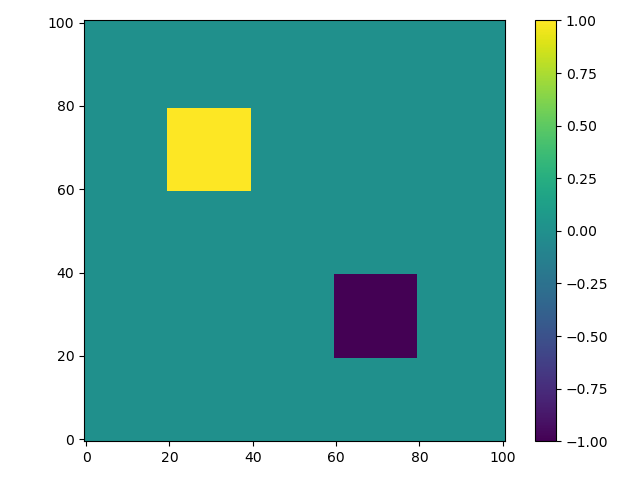

In [16]:
M = 100 # grid size
V = 1

target = 2**-16

phi = np.zeros([M+1, M+1], float)

phi[20:40, 60:80] = V

phi[60:80, 20:40] = -V

fig3, ax3 = plt.subplots()
image = ax3.imshow(phi.T, origin='lower')
plt.colorbar(image)
fig3.tight_layout()

Text(0, 0.5, 'y')

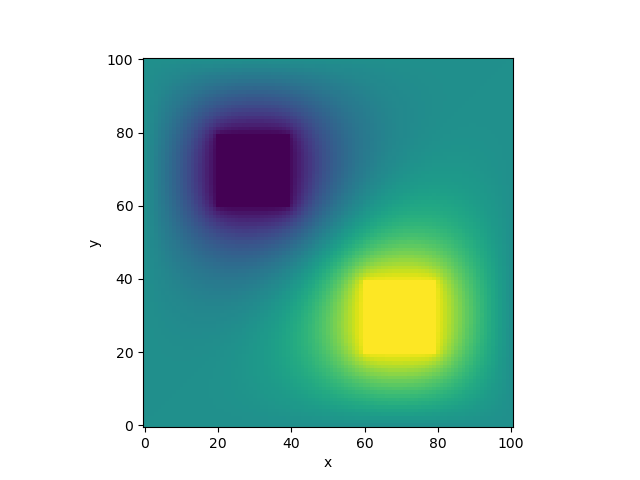

In [7]:
dphi = np.empty([M+1,M+1],float)
omega = 0.9

delta = 1.0
while delta>target:
    for i in range(M+1):
        for j in range(M+1):
            if i==0 or i==M or j==0 or j==M or (20<=i<40 and 60<=j<80) or (60<=i<80 and 20<=j<40): # so this is around the boundary
                phi[i,j] = phi[i,j]
                dphi[i,j] = 0
            else:
                dphi[i,j] = (1+omega)*((phi[i+1,j]+phi[i-1,j]+phi[i,j+1]+phi[i,j-1])/4-phi[i,j])
                phi[i,j] = phi[i,j]+dphi[i,j]
    delta = np.max(np.abs(dphi))

fig4, ax4 = plt.subplots()
ax4.imshow(phi, origin='lower')
ax4.set_xlabel('x')
ax4.set_ylabel('y')

## Ok but I'm not sure that is what the question is asking and I think I mislead the students.

I think the question is coming from painting in the charge density, not painting in the voltage, and that difference is important.

$$\nabla^2 \phi = -\frac{\rho}{\epsilon_0}$$

which means we are designating the boundaries of some charge density... no voltage.

Which means that to first order approximation:

$$\nabla^2 \phi = \frac{\partial^2 \phi^2}{\partial x} + \frac{\partial^2 \phi}{\partial y^2} = \frac{\phi(x+a,y)+\phi(x-a,y)+\phi(x,y+a)+\phi(x,y-a)-4\phi(x,y)}{a^2}$$

So, if that is equal to zero, then we have the formula that we used up above:

$$\frac{\phi(x+a,y)+\phi(x-a,y)+\phi(x,y+a)+\phi(x,y-a)-4\phi(x,y)}{a^2} = 0$$

$$\phi(x+a,y)+\phi(x-a,y)+\phi(x,y+a)+\phi(x,y-a)-4\phi(x,y) = 0 $$

$$\phi(x+a,y)+\phi(x-a,y)+\phi(x,y+a)+\phi(x,y-a)=4\phi(x,y) $$

$$\frac{\phi(x+a,y)+\phi(x-a,y)+\phi(x,y+a)+\phi(x,y-a)}{4}=\phi(x,y) $$

And that is just fine. But when this is Poisson's equation then things change a bit

$$\frac{\phi(x+a,y)+\phi(x-a,y)+\phi(x,y+a)+\phi(x,y-a)-4\phi(x,y)}{a^2} = \frac{\rho}{\epsilon_0}$$

So rearranging this means that $a^2$ sticks around with the $\rho/\epsilon$.

$$\phi(x,y) = \frac{1}{4}(\phi(x+a,y)+\phi(x-a,y)+\phi(x,y+a)+\phi(x,y-a) + a^2\frac{\rho}{\epsilon_0})$$

Now, don't forget that $\rho$ is a spacial dependent quantity. So we should really define at the beginning a matrix for $\rho$ and then we can use it in what comes after.

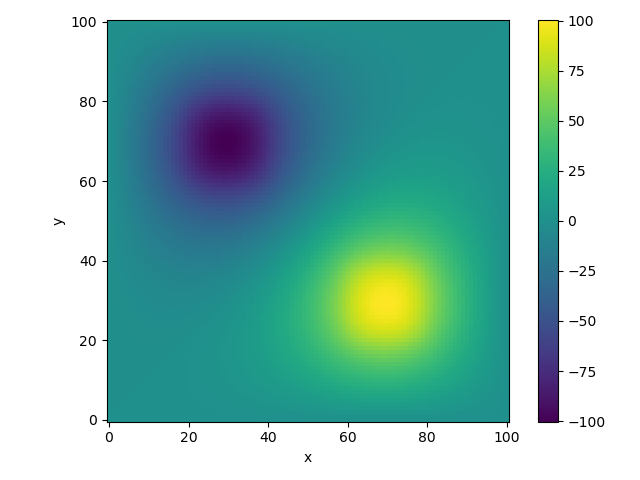

In [11]:
M = 100 # grid size
V = 1

target = 2**-16

phi = np.zeros([M+1, M+1], float)

rho_0 = 1

rho = np.zeros([M+1, M+1], float)

rho[20:40, 60:80] = rho_0

rho[60:80, 20:40] = -rho_0

dphi = np.empty([M+1,M+1],float)
omega = 0.9

delta = 1.0
while delta>target:
    for i in range(M+1):
        for j in range(M+1):
            # this time I don't need that weird boundary so this is nice!
            if i==0 or i==M or j==0 or j==M: 
                # continue
                phi[i,j] = phi[i,j]
                dphi[i,j] = 0
            else:
                dphi[i,j] = (phi[i+1,j]+phi[i-1,j]+phi[i,j+1]+phi[i,j-1]+rho[i,j])/4-phi[i,j]
                phi[i,j] = phi[i,j]+(1+omega)*dphi[i,j]
    delta = np.max(np.abs(dphi))

fig4, ax4 = plt.subplots()
image = ax4.imshow(phi, origin='lower')
ax4.set_xlabel('x')
ax4.set_ylabel('y')
plt.colorbar(image)
fig4.tight_layout()

Now I want to subtly mess with things to optimize them all the way. like do i even need that dphi matrix at all?

Text(0, 0.5, 'y')

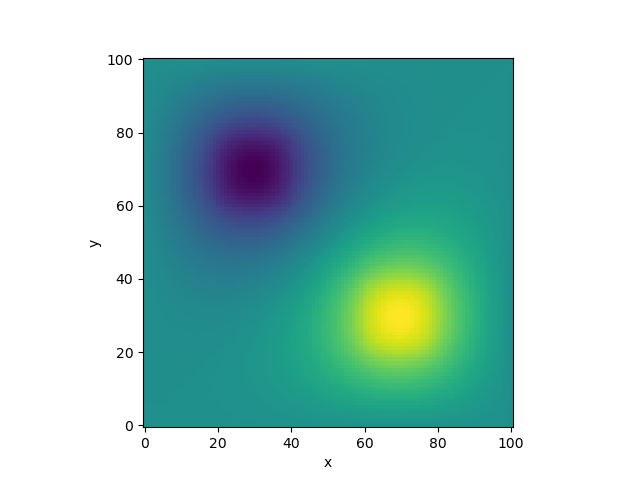

In [23]:
M = 100 # grid size
V = 1

phi = np.zeros([M+1, M+1], float)

phi[0,:] = V

rho_0 = 1

rho = np.zeros([M+1, M+1], float)

rho[20:40, 60:80] = rho_0

rho[60:80, 20:40] = -rho_0

dphi = np.empty([M+1,M+1],float)
omega = 0.9

delta = 1.0
while delta>target:
    for i in range(M):
        for j in range(M):
            # this time I don't need that weird boundary so this is nice!
            if i!=0 or i!=M or j!=0 or j!=M: 
                dphi[i,j] = (phi[i+1,j]+phi[i-1,j]+phi[i,j+1]+phi[i,j-1]+rho[i,j])/4-phi[i,j]
                phi[i,j] = phi[i,j]+(1+omega)*dphi[i,j]
    delta = np.max(np.abs(dphi))

fig4, ax4 = plt.subplots()
ax4.imshow(phi, origin='lower')
ax4.set_xlabel('x')
ax4.set_ylabel('y')